# Plugging in your own forward model

Any code that turns a point source into seismograms can join the library: subclass `Simulator`, implement
`generic_point_source_simulation`, and register a builder under a new `simulation_type` with
`register_simulator`. A configuration then names it exactly as it names Instaseis or CPS, and the station time
shifts, the nuisance effects, dataset generation and every inversion work with it unchanged. The shipped forward
models, the receivers and the nuisance effects are described in the documentation (`docs/simulators.md`).

The model here is a toy that needs no database: the far-field P wave in a homogeneous whole space (Aki &
Richards, eq. 4.29),

$$u(\mathbf{x}, t) = \frac{(\boldsymbol\gamma^\mathsf{T} M \boldsymbol\gamma)\,\boldsymbol\gamma}{4\pi\rho\alpha^3 r}\,\dot s\!\left(t - \frac{r}{\alpha}\right),$$

with $\boldsymbol\gamma$ the unit vector from source to receiver and $\dot s$ a Gaussian moment-rate pulse of
unit area. It is registered, built from simulation parameters, and used to invert a noisy observation of a known
source recorded by twelve stations on two rings, 15 and 40 km from the epicentre, so that the P waves leave the
source at a spread of take-off angles. The notebook runs in a few seconds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from obspy.geodetics import gps2dist_azimuth
from pyrocko import orthodrome

from seismo_sbi.moment_tensor.comparison import kagan
from seismo_sbi.sbi.compression.gaussian import GaussianCompressor, ScoreCompressionData
from seismo_sbi.sbi.noises.diagonal_covariances import ScalarEmpiricalCovariance
from seismo_sbi.sbi.types.parameters import SimulationParameters
from seismo_sbi.simulators.base import Simulator
from seismo_sbi.simulators.receivers import Receivers
from seismo_sbi.simulators.registry import build_simulator, register_simulator
from seismo_sbi.simulators.simulation_io import seismogram_map_to_array

SAMPLING_RATE_HZ = 1.0
DURATION_S = 40
SOURCE_LOCATION = [37.636, -118.936, 10.0, 0.0]  # latitude, longitude, depth_km, time shift s
stations = [(f"R{distance_km:02d}{azimuth_deg:03d}", *orthodrome.azidist_to_latlon(
    SOURCE_LOCATION[0], SOURCE_LOCATION[1], azimuth_deg, distance_km / 111.19))
    for distance_km in (15, 40) for azimuth_deg in range(0, 360, 60)]
receivers = Receivers.from_arrays([name for name, _, _ in stations], ["XX"] * len(stations),
                                  [float(lat) for _, lat, _ in stations], [float(lon) for _, _, lon in stations])

## The forward model and its registration

`generic_point_source_simulation` receives the source (a location: latitude, longitude, depth in km, time shift
in s; and the six moment-tensor components `m_rr, m_tt, m_pp, m_rt, m_rp, m_tp` in N m) and returns
`{station: {component: trace}}`; `pre_event_pad_s` says how long before the origin time each trace starts.
The builder turns the simulation parameters a configuration is parsed into
(receivers, components, duration, processing) into the simulator.

In [2]:
class HomogeneousPWaveSimulator(Simulator):
    """Far-field P wave in a homogeneous whole space, as displacement in metres."""

    pre_event_pad_s = 10.0
    p_velocity_m_s = 6000.0
    density_kg_m3 = 2700.0
    pulse_width_s = 1.5

    def generic_point_source_simulation(self, source, **kwargs):
        location = source.source_location
        m_rr, m_tt, m_pp, m_rt, m_rp, m_tp = source.moment_tensor.components
        moment_tensor = np.array([[m_rr, m_rt, m_rp], [m_rt, m_tt, m_tp], [m_rp, m_tp, m_pp]])
        time_s = np.arange(int(self.seismogram_length * SAMPLING_RATE_HZ) + 1) / SAMPLING_RATE_HZ             - self.pre_event_pad_s - location.time_shift
        seismograms = {}
        for receiver in self.receivers.iterate():
            epicentral_m, azimuth_deg, _ = gps2dist_azimuth(location.latitude, location.longitude,
                                                            receiver.latitude, receiver.longitude)
            azimuth = np.radians(azimuth_deg)
            ray = np.array([location.depth * 1e3, -epicentral_m * np.cos(azimuth), epicentral_m * np.sin(azimuth)])
            distance_m = np.linalg.norm(ray)
            gamma = ray / distance_m  # up, south, east
            moment_rate = np.exp(-0.5 * ((time_s - distance_m / self.p_velocity_m_s) / self.pulse_width_s) ** 2) \
                / (self.pulse_width_s * np.sqrt(2 * np.pi))
            amplitude = gamma @ moment_tensor @ gamma / (4 * np.pi * self.density_kg_m3 * self.p_velocity_m_s ** 3 * distance_m)
            up, south, east = amplitude * gamma[:, None] * moment_rate
            seismograms[receiver.station_name] = {"Z": up, "N": -south, "E": east}
        return seismograms


def build_homogeneous_p_wave(simulation_parameters, simulator_config, post_processing_effects, data_flattening):
    return HomogeneousPWaveSimulator(
        components=simulation_parameters.components, receivers=simulation_parameters.receivers,
        seismogram_duration_in_s=simulation_parameters.seismogram_duration,
        synthetics_processing=simulation_parameters.processing, post_processing_effects=post_processing_effects)


register_simulator("homogeneous_p_wave", build_homogeneous_p_wave)
simulation_parameters = SimulationParameters(
    receivers=receivers, components="ZNE", seismogram_duration=DURATION_S, syngine_address=None,
    sampling_rate=SAMPLING_RATE_HZ, processing={"sampling_rate": SAMPLING_RATE_HZ}, simulation_type="homogeneous_p_wave")
simulator = build_simulator((simulation_parameters.simulation_type, None), simulation_parameters)
print(type(simulator).__name__, "at", len(receivers.receivers), "stations")

HomogeneousPWaveSimulator at 12 stations


## An inversion with it

The toy is linear in the moment tensor, so six simulations of unit tensors at the source position give the
kernels $G$, shape `(6, n_data)`. The observation is the seismograms of a known source plus white noise of
1 % of their peak; score compression with that noise gives the Gaussian-likelihood posterior in closed form,
its mean the least-squares tensor and its covariance the inverse Fisher matrix.

In [3]:
TRUE_MOMENT_TENSOR = np.array([1.0e17, -0.6e17, -0.4e17, 0.3e17, -0.5e17, 0.2e17])  # N m
simulate = lambda m6: seismogram_map_to_array(simulator.run_simulation(
    {"source_location": SOURCE_LOCATION, "moment_tensor": list(m6)})[1], receivers)
kernels = np.array([simulate(unit) for unit in np.eye(6)])
clean = simulate(TRUE_MOMENT_TENSOR)
noise_level_m = 0.01 * np.abs(clean).max()
observed = clean + np.random.default_rng(0).normal(0.0, noise_level_m, clean.size)

compressor = GaussianCompressor(ScoreCompressionData(np.zeros(6), np.zeros(clean.size), kernels, None),
                                ScalarEmpiricalCovariance(noise_level_m, clean.size))
mean, covariance = compressor.compress_data_vector(observed), compressor.Fisher_mat_inverse
for name, truth, estimate, sigma in zip(["m_rr", "m_tt", "m_pp", "m_rt", "m_rp", "m_tp"], TRUE_MOMENT_TENSOR, mean,
                                        np.sqrt(np.diag(covariance))):
    print(f"{name}: true {truth:9.2e}  posterior {estimate:9.2e} +- {sigma:.1e} N m  ({(estimate - truth) / sigma:+.1f} sigma)")
print(f"Kagan angle to the true tensor {kagan(mean, TRUE_MOMENT_TENSOR):.2f} deg")

m_rr: true  1.00e+17  posterior  9.93e+16 +- 8.9e+14 N m  (-0.8 sigma)
m_tt: true -6.00e+16  posterior -6.00e+16 +- 4.0e+14 N m  (-0.1 sigma)
m_pp: true -4.00e+16  posterior -3.95e+16 +- 4.0e+14 N m  (+1.2 sigma)
m_rt: true  3.00e+16  posterior  3.01e+16 +- 1.8e+14 N m  (+0.4 sigma)
m_rp: true -5.00e+16  posterior -4.99e+16 +- 1.8e+14 N m  (+0.3 sigma)
m_tp: true  2.00e+16  posterior  2.01e+16 +- 2.1e+14 N m  (+0.7 sigma)
Kagan angle to the true tensor 0.21 deg


The observed traces (black) and the synthetics of the posterior mean (red), vertical component.

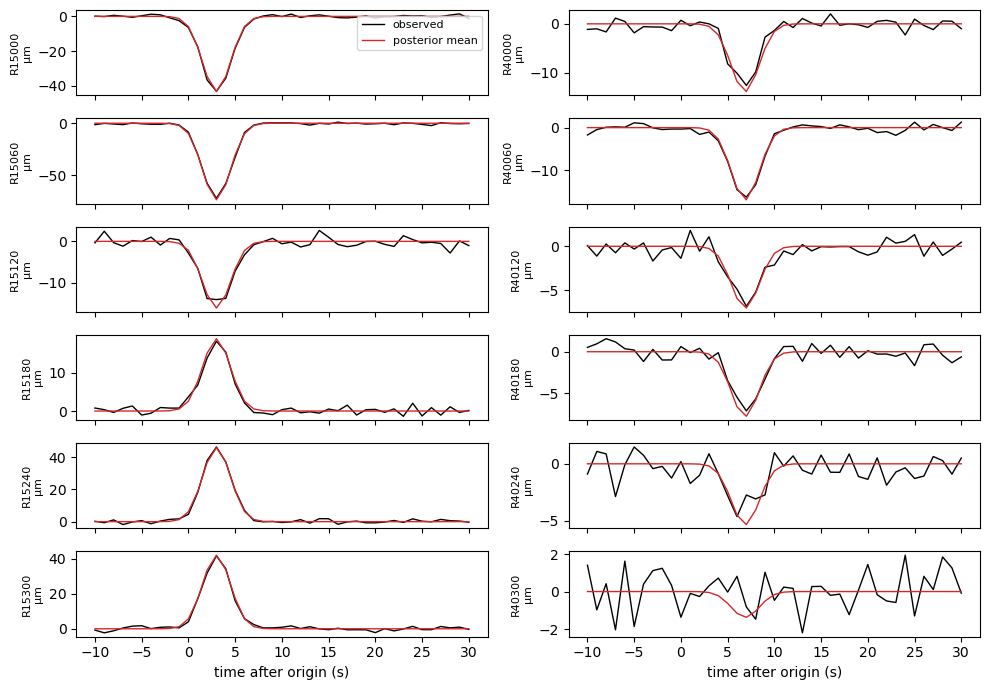

In [4]:
time_s = np.arange(kernels.shape[1] // (3 * len(receivers.receivers))) / SAMPLING_RATE_HZ - simulator.pre_event_pad_s
fitted = (kernels.T @ mean).reshape(len(receivers.receivers), 3, -1)
data = observed.reshape(len(receivers.receivers), 3, -1)
fig, axes = plt.subplots(6, 2, figsize=(10, 7), sharex=True)
for ax, receiver, observed_trace, fitted_trace in zip(axes.T.ravel(), receivers.iterate(), data[:, 0], fitted[:, 0]):
    ax.plot(time_s, observed_trace * 1e6, "k", lw=1.0, label="observed")
    ax.plot(time_s, fitted_trace * 1e6, "C3", lw=1.0, label="posterior mean")
    ax.set_ylabel(f"{receiver.station_name}\nµm", fontsize=8)
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes[-1]:
    ax.set_xlabel("time after origin (s)")
fig.tight_layout()
plt.show()